# **Denetimsiz Öğrenme**

1. K means Clustering
2. Hierarchical Clustering
3. DBSCAN
4. Gaussian Mixture Model
5. Pca


In [1]:
# Temel kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#veri ön işleme
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


# Algoritmalar ( Kümeleme)
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

#Boyut indirme
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#Değerlendirme Metrikleri

from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score


from scipy.cluster.hierarchy import dendrogram, linkage


plt.rcParams['figure.figsize'] = [16, 10]
plt.rcParams['font.size'] = 14
sns.set_style('whitegrid')
print('Herşey hazır')


Herşey hazır


In [2]:
data =pd.read_csv('Country-data.csv')
df=data.copy()

In [3]:
print(f'Veri Seti Boyutu: {df.shape}')
print(f'Sutun sayisi:{len(df.columns)}')
print(f'Satır Sayısı:{len(df)}')

Veri Seti Boyutu: (167, 10)
Sutun sayisi:10
Satır Sayısı:167


In [4]:
#veri seti bilgisi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
#Istatıksel Ozet
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [6]:
print('Eksik değerler')
print('--'*50)
print(df.isnull().sum()[df.isnull().sum()>0])
print(f'toplam eksik değer: {df.isnull().sum().sum()}')
print('--'*50)

Eksik değerler
----------------------------------------------------------------------------------------------------
Series([], dtype: int64)
toplam eksik değer: 0
----------------------------------------------------------------------------------------------------


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [8]:
df_columns =df.columns.str.strip()

In [11]:
df_numeric = df.select_dtypes(include=np.number)

print('Eksik değerler')
print('--'*50)
print(df_numeric.isnull().sum()[df_numeric.isnull().sum()>0])
print(f'toplam eksik değer: {df_numeric.isnull().sum().sum()}')

Eksik değerler
----------------------------------------------------------------------------------------------------
Series([], dtype: int64)
toplam eksik değer: 0


In [13]:
scaler= StandardScaler()
x_scaled=scaler.fit_transform(df_numeric)
x_scaled=pd.DataFrame(x_scaled,columns=df_numeric.columns,index=df_numeric.index)

print('Ölçeklenmiş veri seti')
print('--'*50)
x_scaled.head(2)

Ölçeklenmiş veri seti
----------------------------------------------------------------------------------------------------


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623


In [14]:
df.head(2)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090


## **K means**

Veri setini k adet kümeye ayıran bir algoritma

parametreleri:


*   n_Cluster küme sayısı
*   init  başlangıç seçme yöntemi
*   n_init farklı başlangıçlarla çalıştırma sayısı
*   max_iter maksimum iterasyon sayısı


Küme sayısı belirleme yöntemleri
*  elbow
* silhoutte
*  Davies Bouldin

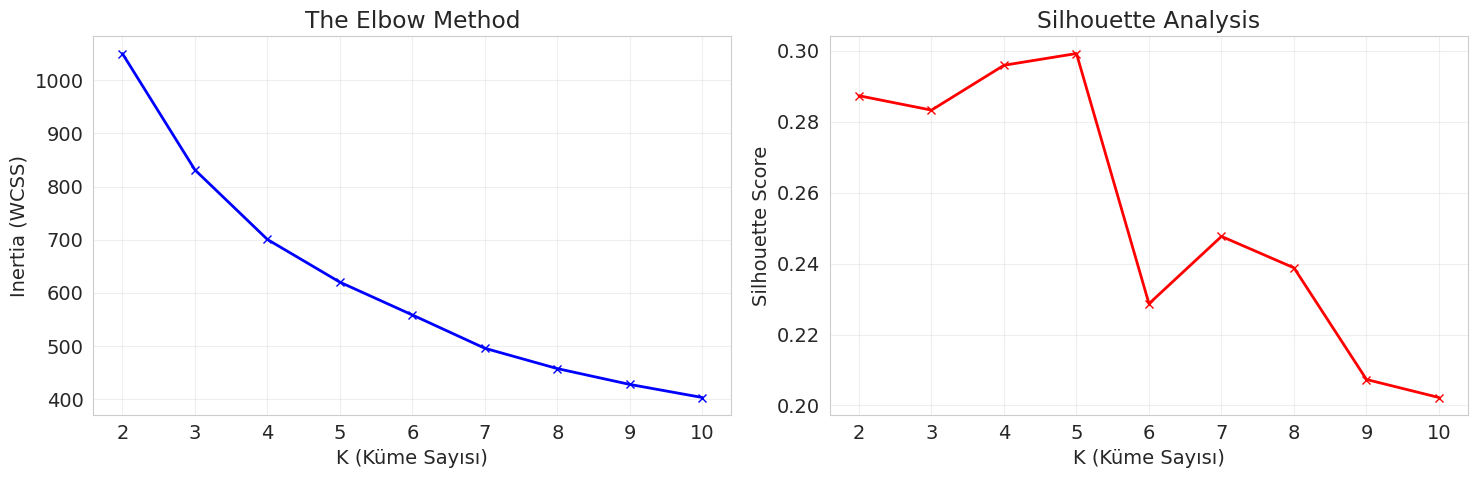

En iyi silhouette skoru: 0.2993
Optimum küme sayısı: 5


In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score # Fonksiyon tekil

# 1. Listeleri tanımla
inertia = []
silhouette_scores = [] # Liste çoğul
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Değişken adının X_scaled (büyük X) olduğundan emin ol
    labels = kmeans.fit_predict(x_scaled)

    inertia.append(kmeans.inertia_)
    # Liste ismine (çoğul), fonksiyonun (tekil) sonucunu ekle
    silhouette_scores.append(silhouette_score(x_scaled, labels))

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sol Grafik: Elbow Method
axes[0].plot(K_range, inertia, 'bx-', linewidth=2)
axes[0].set_xlabel('K (Küme Sayısı)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('The Elbow Method')
axes[0].grid(True, alpha=0.3)

# Sağ Grafik: Silhouette Score
# Hata Buradaydı: 'silhouette_score' (fonksiyon) yerine 'silhouette_scores' (liste) olmalı
axes[1].plot(K_range, silhouette_scores, 'rx-', linewidth=2)
axes[1].set_xlabel('K (Küme Sayısı)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# En iyi K değerini hesapla
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'En iyi silhouette skoru: {max(silhouette_scores):.4f}')
print(f'Optimum küme sayısı: {optimal_k}')

In [16]:
# Optimum  K ile  K-Means modelini egit
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42,n_init=10)
kmeans_labels=kmeans.fit_predict(x_scaled)

print('K-means Kümeleme Sonuçları:')
print(f'Kume sayısı: {optimal_k}')
print(f'Silhoutte Skoru: {silhouette_score(x_scaled, kmeans_labels):.4f}')
print(f'Davies Bouldin Skoru: {davies_bouldin_score(x_scaled, kmeans_labels):.4f}')
print(f'Calinski Harabasz Skoru: {calinski_harabasz_score(x_scaled, kmeans_labels):.4f}')
print(f'\n Kume dagilimi:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-means Kümeleme Sonuçları:
Kume sayısı: 4
Silhoutte Skoru: 0.2960
Davies Bouldin Skoru: 1.0530
Calinski Harabasz Skoru: 62.2414

 Kume dagilimi:
0    32
1    47
2    85
3     3
Name: count, dtype: int64


In [19]:
# K-Means kumelerinin ozetleri
# KMeans_Cluster etiketlerini sayısal verilerin bulunduğu DataFrame'e ekleyelim
df_for_clustering_summary = df_numeric.copy()
df_for_clustering_summary['KMeans_Cluster'] = kmeans_labels

cluster_summary = df_for_clustering_summary.groupby('KMeans_Cluster').mean().round(2)
print('K-Means Kume Profilleri:')
cluster_summary

K-Means Kume Profilleri:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.18,46.12,9.09,40.58,44021.88,2.51,80.08,1.79,42118.75
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.69,41.07,6.20,47.91,12671.41,7.61,72.87,2.30,6519.55
3,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67


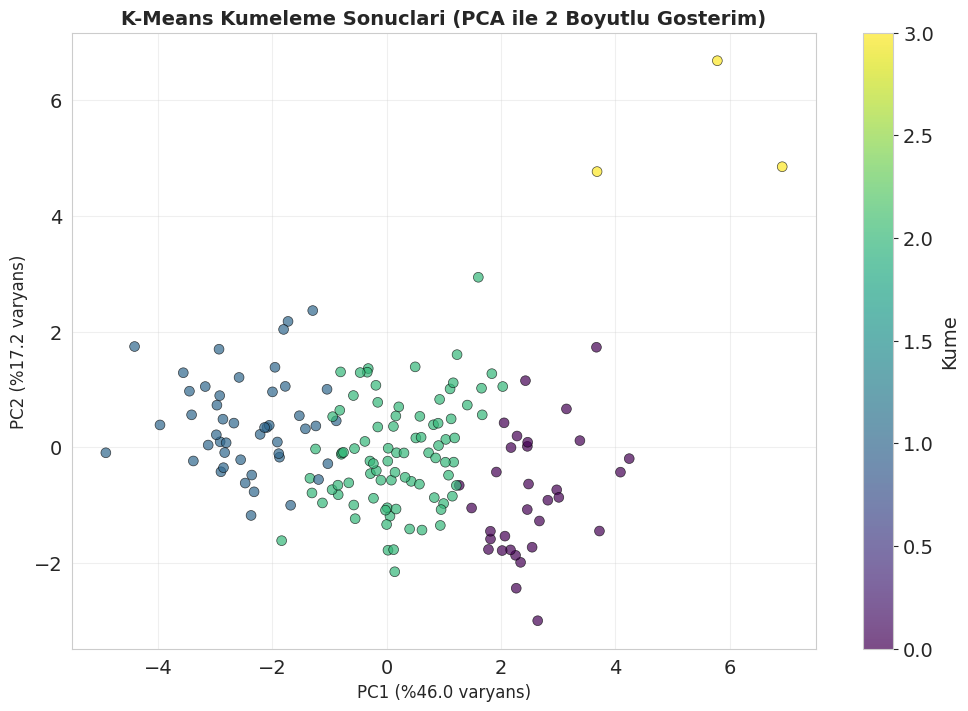

In [20]:
# PCA ile K-Means gorsellestirmesi
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('K-Means Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# **Hiyerarşik kümeleme**

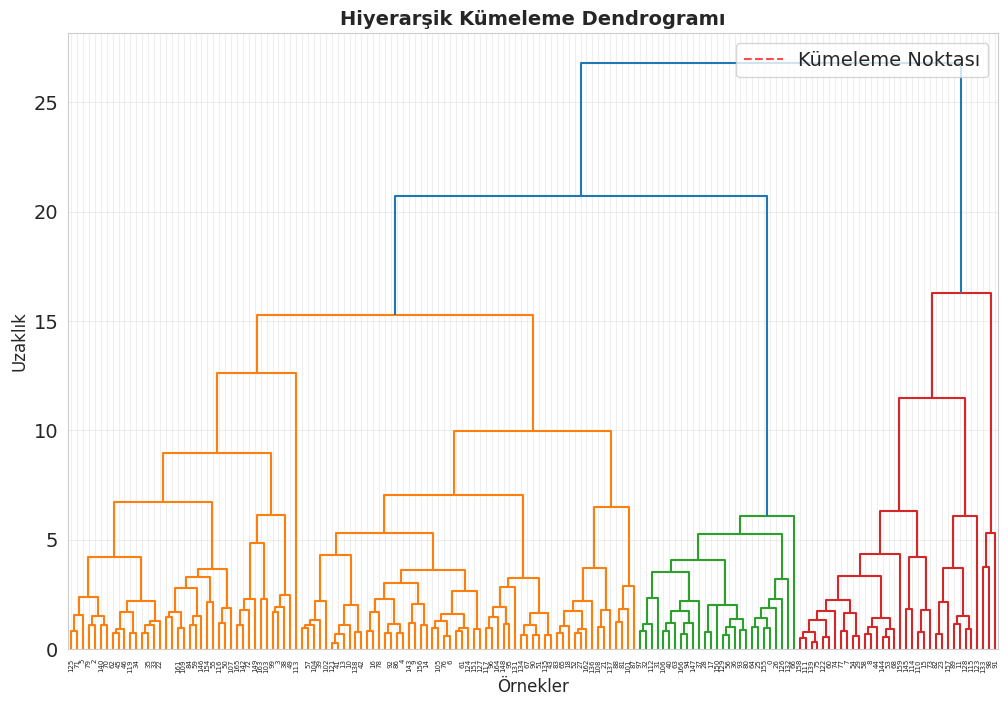

In [21]:
plt.figure(figsize=(12,8))
linked = linkage(x_scaled[:200],method='ward')
dendrogram(linked,orientation='top',distance_sort='descending',show_leaf_counts=False,truncate_mode='level',p=10)
plt.title('Hiyerarşik Kümeleme Dendrogramı', fontsize=14, fontweight='bold')
plt.xlabel('Örnekler', fontsize=12)
plt.ylabel('Uzaklık', fontsize=12)
plt.axhline(y=30,color='r',linestyle='--',alpha=0.7,label='Kümeleme Noktası')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
# Agglomerative
agg_clustering  =AgglomerativeClustering(n_clusters=optimal_k,linkage='ward')
agg_labels=agg_clustering.fit_predict(x_scaled)

print('Hiyerarşik (Agglomerative)Kümeleme Sonuçları:')
print(f'Kümeleme Sayısı: {optimal_k}')
print(f'Bağlantı Yöntemi :ward')
print(f'Silhoutte Skoru: {silhouette_score(x_scaled, agg_labels):.4f}')
print(f'Davies Bouldin Skoru: {davies_bouldin_score(x_scaled, agg_labels):.4f}')
print(f'Calinski Harabasz Skoru: {calinski_harabasz_score(x_scaled, agg_labels):.4f}')
print(f'\n Kume dagilimi:')
print(pd.Series(agg_labels).value_counts().sort_index())

Hiyerarşik (Agglomerative)Kümeleme Sonuçları:
Kümeleme Sayısı: 4
Bağlantı Yöntemi :ward
Silhoutte Skoru: 0.2481
Davies Bouldin Skoru: 1.0801
Calinski Harabasz Skoru: 48.2626

 Kume dagilimi:
0    106
1     31
2     27
3      3
Name: count, dtype: int64


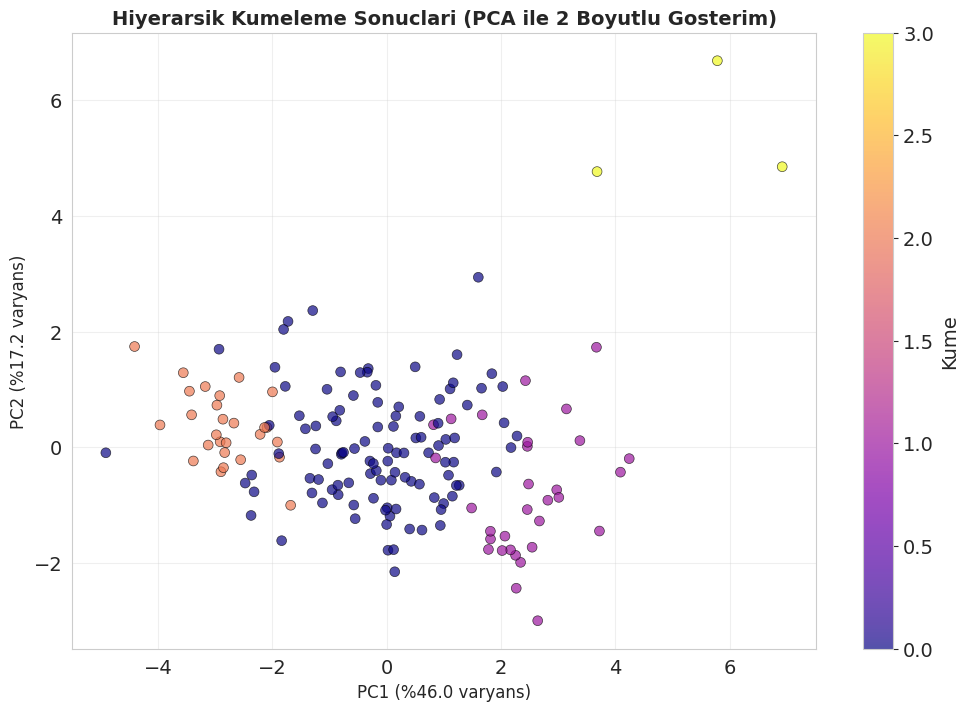

In [23]:
# Hiyerarsik kumelerin gorsellestirmesi
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='plasma',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('Hiyerarsik Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## **Dbscan**

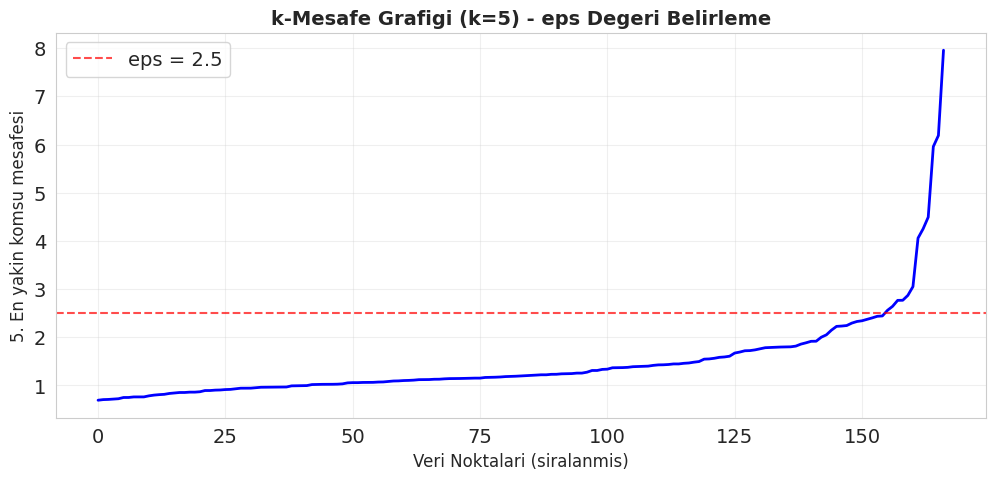

In [24]:
#dbscan
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(x_scaled)
distances, indices = neighbors_fit.kneighbors(x_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(12, 5))
plt.plot(distances, 'b-', linewidth=2)
plt.title('k-Mesafe Grafigi (k=5) - eps Degeri Belirleme', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari (siralanmis)', fontsize=12)
plt.ylabel('5. En yakin komsu mesafesi', fontsize=12)
plt.axhline(y=2.5, color='r', linestyle='--', alpha=0.7, label='eps = 2.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
dbscan= DBSCAN(eps=2.5,min_samples=5)
dbscan_labels=dbscan.fit_predict(x_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise =list(dbscan_labels).count(-1)

print('DBSCAN Kümeleme Sonuçları:')
print(f'Kümeleme Sayısı: {n_clusters_db}')
print(f'Gürültü Sayısı: {n_noise}')
print(f'Gürültü oranı: {n_noise/len(dbscan_labels):.4f}')

if n_clusters_db >1:
  print(f'Silhoutte Skoru: {silhouette_score(x_scaled, dbscan_labels):.4f}')
  print(f'Davies Bouldin Skoru: {davies_bouldin_score(x_scaled, dbscan_labels):.4f}')
  print(f'Calinski Harabasz Skoru: {calinski_harabasz_score(x_scaled, dbscan_labels):.4f}')
print(f'\n Kume dagilimi:')
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN Kümeleme Sonuçları:
Kümeleme Sayısı: 1
Gürültü Sayısı: 6
Gürültü oranı: 0.0359

 Kume dagilimi:
-1      6
 0    161
Name: count, dtype: int64


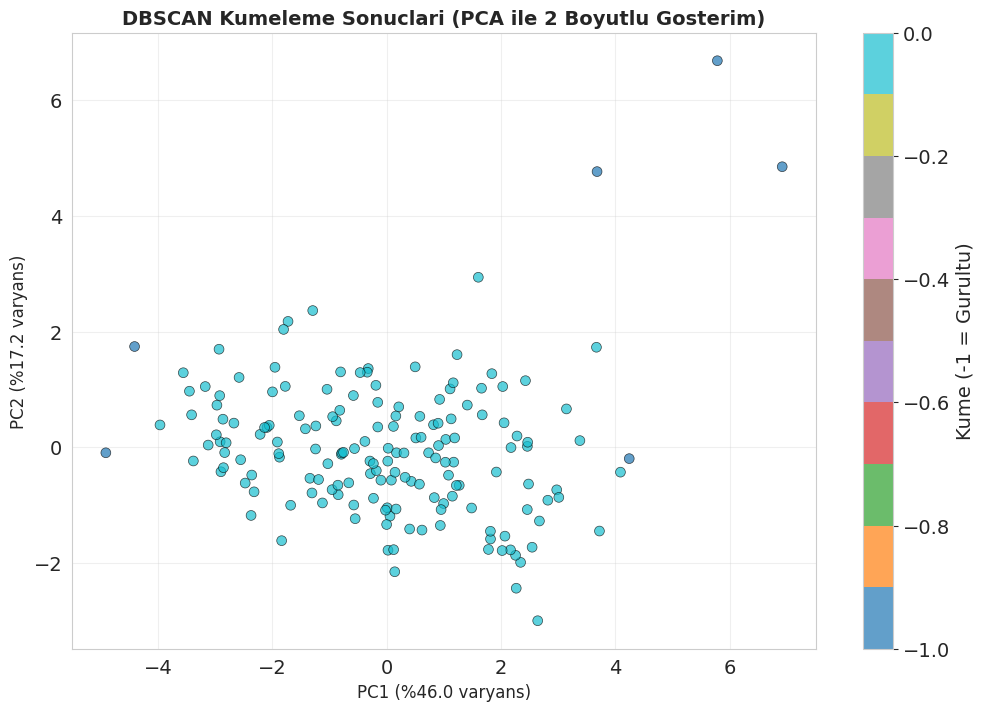

In [26]:
# DBSCAN kumelerinin gorsellestirmesi
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume (-1 = Gurultu)')
plt.title('DBSCAN Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# **Gaussian Mixture Model**

hiperparametreleri

* n_components: bileşen küme sayısı
* covariance_type:kovaryans tipi
* max_iter: maksimum iterasyon sayısı


In [27]:
#gmm

gmm =GaussianMixture(n_components=optimal_k,covariance_type='full',max_iter=200)
gmm_labels=gmm.fit_predict(x_scaled)
gmm_probs=gmm.predict_proba(x_scaled)

print('GMM Kümeleme Sonuçları:')
print(f'Kümeleme Sayısı: {optimal_k}')
print(f'Sihoutte Skoru: {silhouette_score(x_scaled, gmm_labels):.4f}')
print(f'Davies Bouldin Skoru: {davies_bouldin_score(x_scaled, gmm_labels):.4f}')
print(f'Calinski Harabasz Skoru: {calinski_harabasz_score(x_scaled, gmm_labels):.4f}')
print(f'\n Kume dagilimi:')
print(pd.Series(gmm_labels).value_counts().sort_index())

GMM Kümeleme Sonuçları:
Kümeleme Sayısı: 4
Sihoutte Skoru: 0.1937
Davies Bouldin Skoru: 1.3032
Calinski Harabasz Skoru: 43.6428

 Kume dagilimi:
0     3
1    55
2    76
3    33
Name: count, dtype: int64


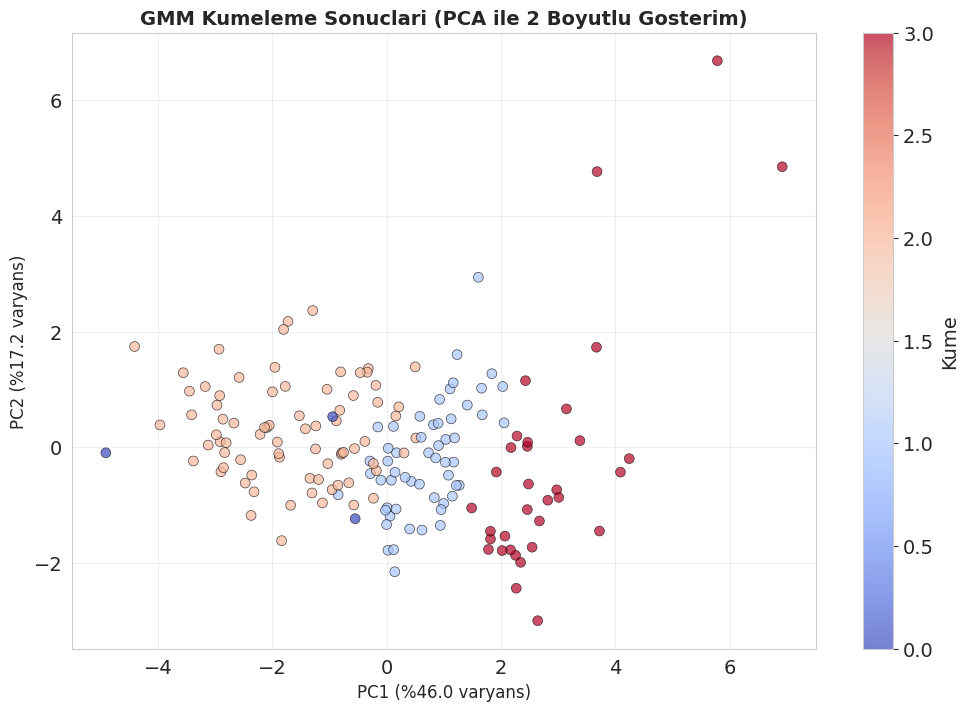

In [28]:
# GMM kumelerinin gorsellestirmesi
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='coolwarm',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('GMM Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()